In [ ]:
import pandas as pd

In [ ]:
data=pd.read_csv("train.csv")

In [ ]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.shape

(614, 13)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [ ]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
(data.isnull().sum()/len(data))*100

,0
Loan_ID,0.000000
Gender,2.117264
Married,0.488599
Dependents,2.442997
Education,0.000000
Self_Employed,5.211726
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,3.583062
Loan_Amount_Term,2.280130


In [ ]:
data.dropna(inplace=True)

In [ ]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

In [ ]:
cat=['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']


<Axes: xlabel='Education', ylabel='Self_Employed'>

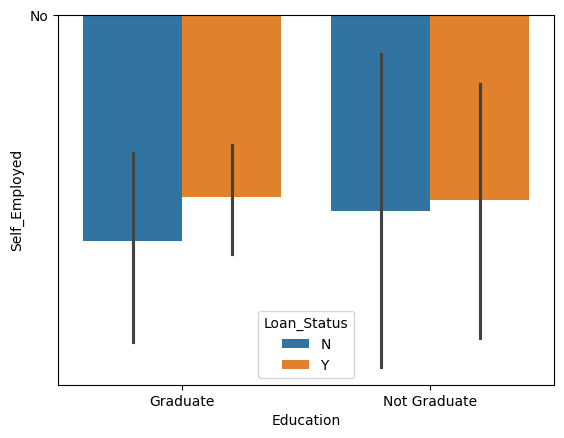

In [ ]:
import seaborn as sns
sns.barplot(x='Education',y='Self_Employed',data=data,hue='Loan_Status')

<Axes: xlabel='Education'>

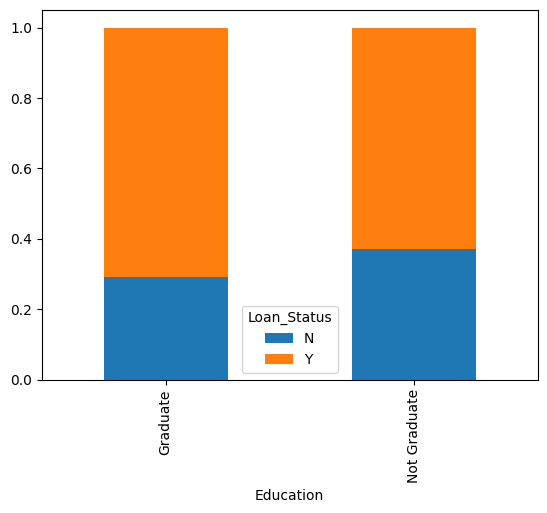

In [ ]:
pd.crosstab(data['Education'],data['Loan_Status'],normalize='index').plot(kind='bar',stacked='True')

<Axes: xlabel='Self_Employed'>

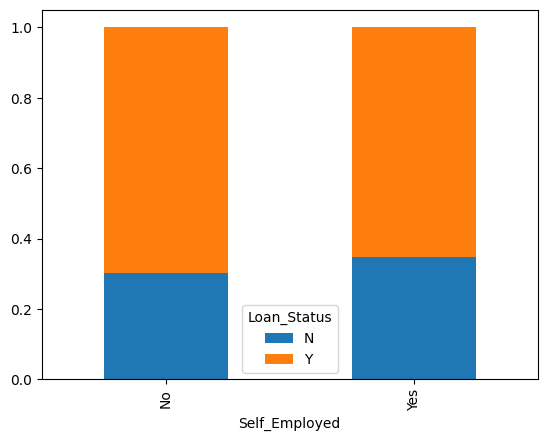

In [ ]:
pd.crosstab(data['Self_Employed'],data['Loan_Status'],normalize='index').plot(kind='bar',stacked='True')

<Axes: xlabel='Married', ylabel='count'>

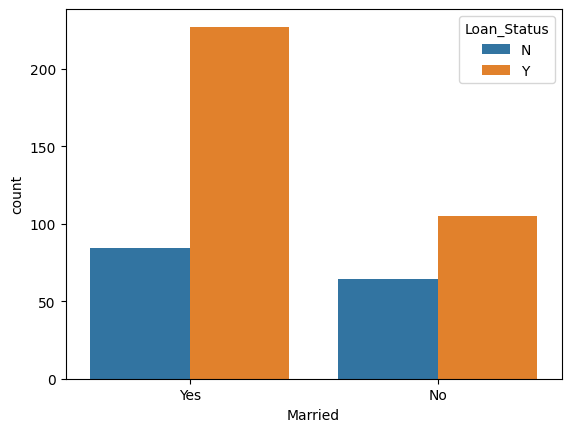

In [ ]:
sns.countplot(x='Married',hue='Loan_Status',data=data)

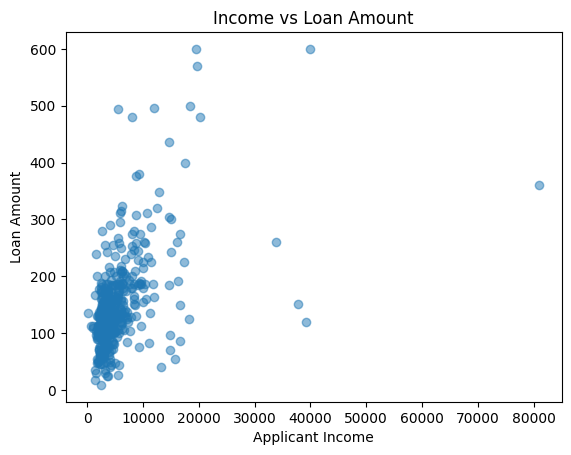

In [ ]:
plt.scatter(
    data['ApplicantIncome'],
    data['LoanAmount'],
    alpha=0.5
)

plt.xlabel("Applicant Income")

plt.ylabel("Loan Amount")

plt.title("Income vs Loan Amount")

plt.show()

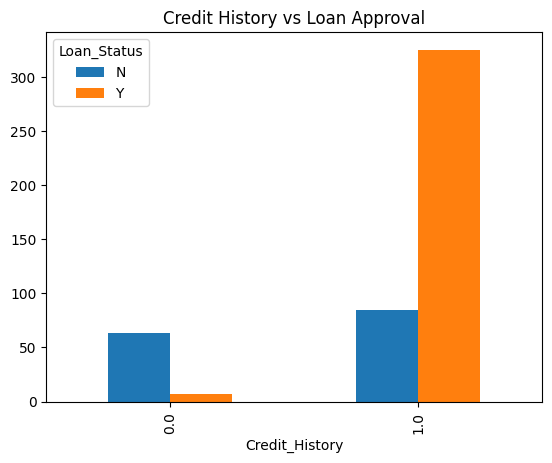

In [ ]:
pd.crosstab(
    data['Credit_History'],
    data['Loan_Status']
).plot(kind='bar')

plt.title("Credit History vs Loan Approval")

plt.show()

In [ ]:
le=LabelEncoder()
for i in cat:
  data[i]=le.fit_transform(data[i])

In [ ]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2,1


In [ ]:
data.drop('Loan_ID',axis=1,inplace=True)

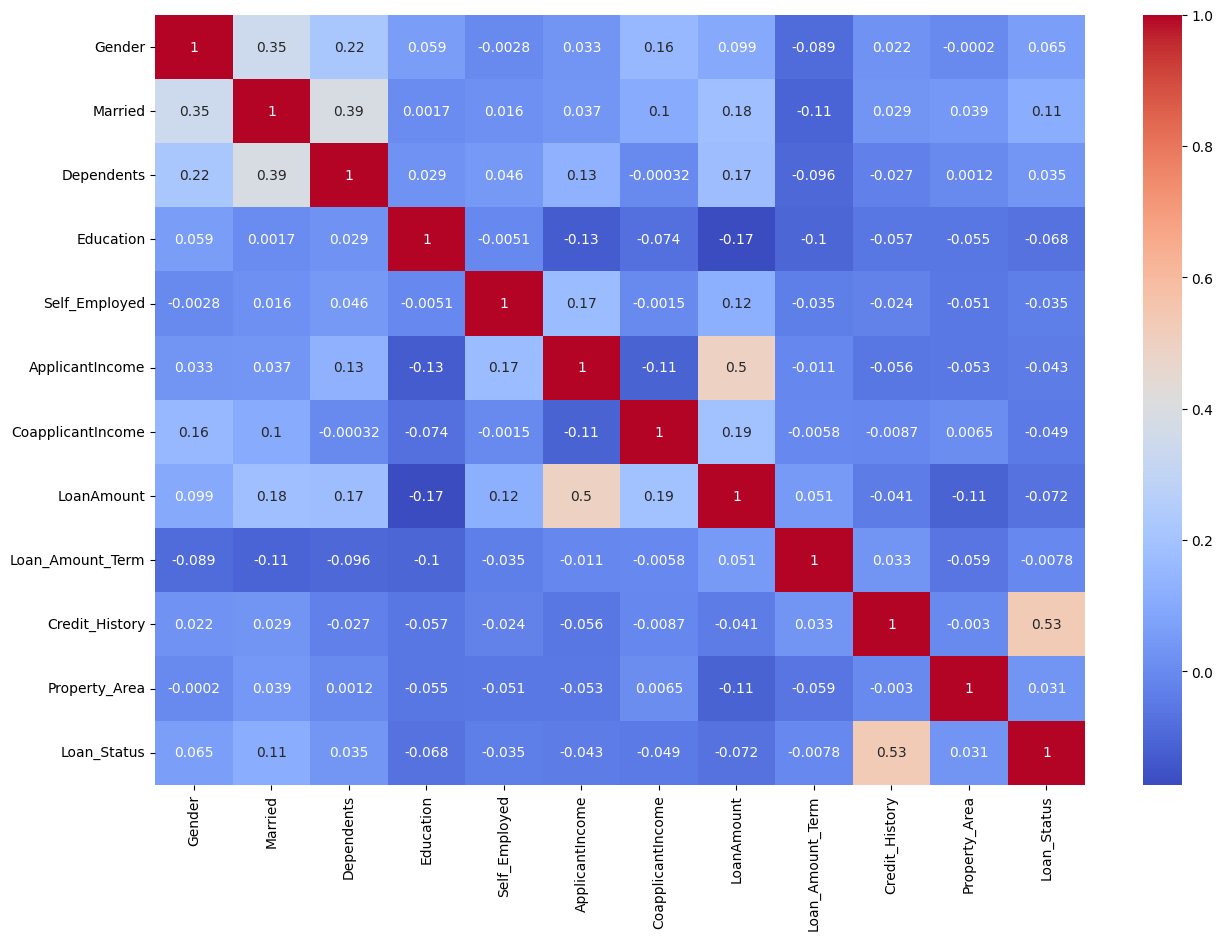

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.show()

<Axes: >

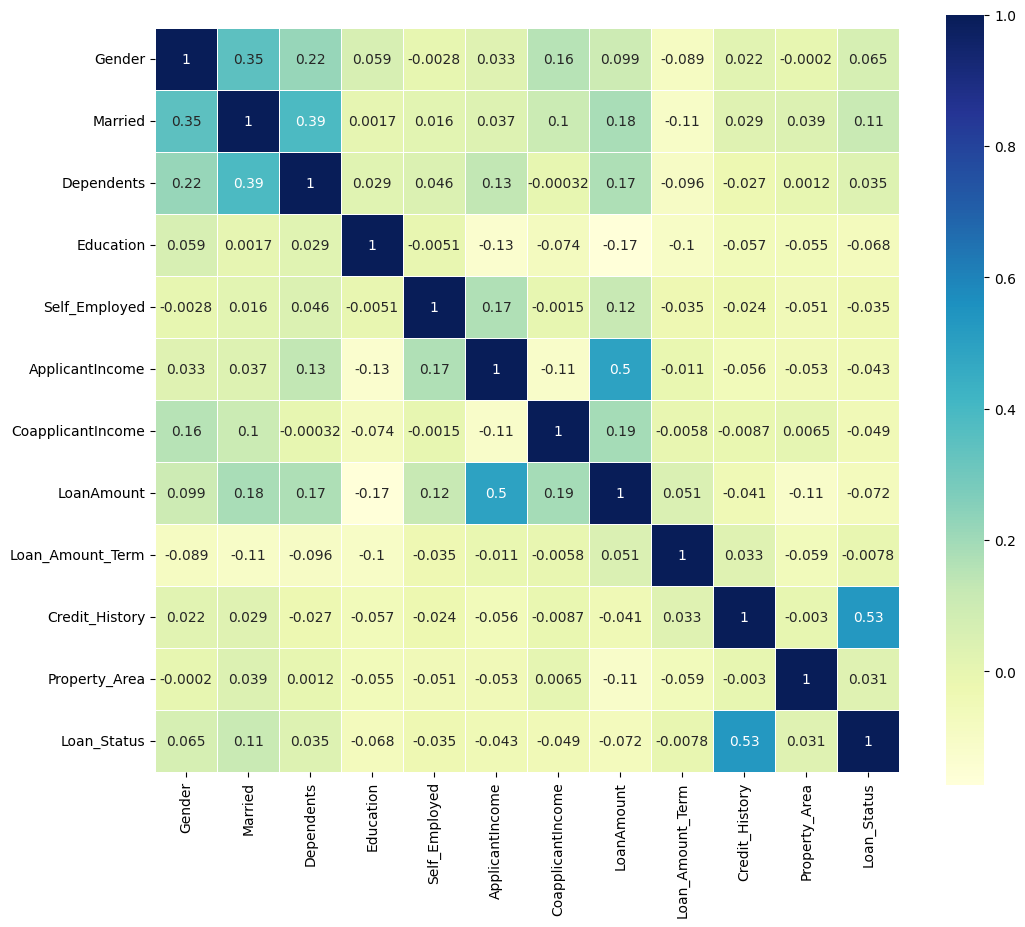

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    data.corr(),
    annot=True,
    linewidths=0.5,
    cmap='YlGnBu',
    square=True
)


In [ ]:
x=data.drop('Loan_Status',axis=1)
y=data['Loan_Status']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
#

In [ ]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [ ]:
y_train.value_counts()

,count
Loan_Status,
1,266
0,118


In [ ]:
sm = SMOTE(random_state=42)

x_train_sm,y_train_sm = sm.fit_resample(
    x_train,
    y_train
)

In [ ]:
lr=LogisticRegression()
lr.fit(x_train_sm,y_train_sm)
pred_lr=lr.predict(x_test)

In [ ]:
print("Precision:",precision_score(y_test,pred_lr))

print("Recall:",recall_score(y_test,pred_lr))

print("F1:",f1_score(y_test,pred_lr))

print("ROC AUC:",roc_auc_score(y_test,pred_lr))

Precision: 0.8484848484848485
Recall: 0.8484848484848485
F1: 0.8484848484848485
ROC AUC: 0.7575757575757577


In [ ]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train_sm,y_train_sm)
pred_rf=rf.predict(x_test)

In [ ]:
print("Precision:",precision_score(y_test,pred_rf))

print("Recall:",recall_score(y_test,pred_rf))

print("F1:",f1_score(y_test,pred_rf))

print("ROC AUC:",roc_auc_score(y_test,pred_rf))

Precision: 0.8333333333333334
Recall: 0.7575757575757576
F1: 0.7936507936507936
ROC AUC: 0.7121212121212122


In [ ]:
prob_lr = lr.predict_proba(x_test)[:, 1]

roc_auc_score(y_test, prob_lr)

np.float64(0.7914141414141415)

In [ ]:
prob_rf = rf.predict_proba(x_test)[:, 1]

roc_auc_score(y_test, prob_rf)

np.float64(0.7977272727272727)

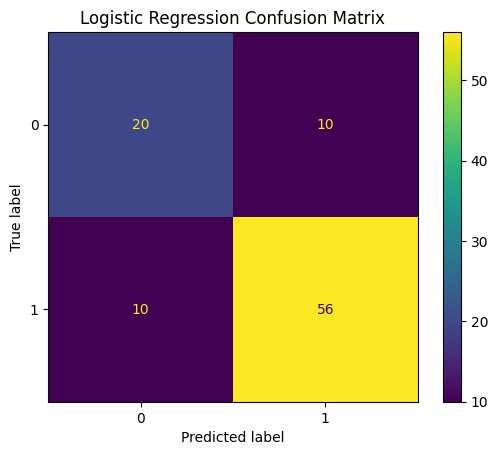

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr, x_test, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

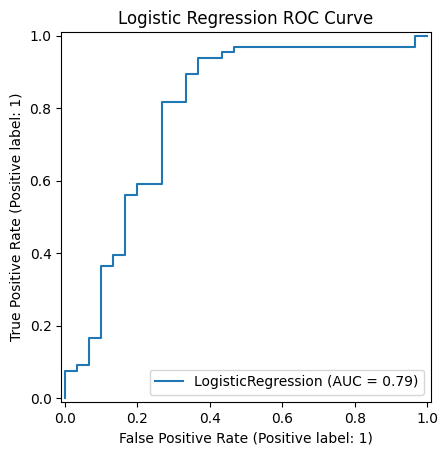

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(lr, x_test, y_test)
plt.title("Logistic Regression ROC Curve")
plt.show()